Bibliotecas importadas com sucesso!


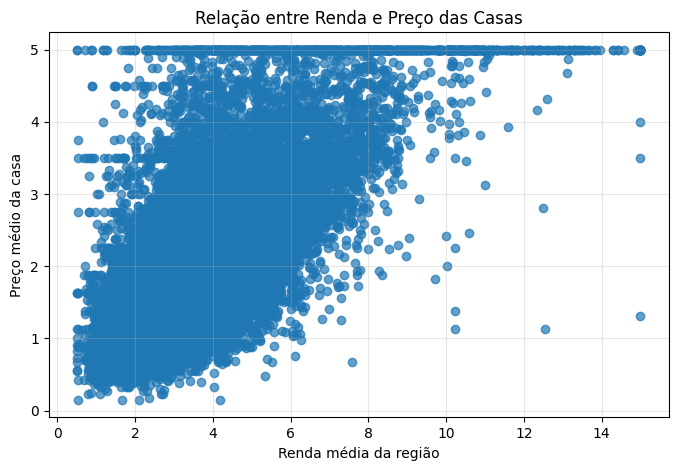


🔹 X (renda média): 20640 registros
🔹 y (preço das casas): 20640 registros

📚 Dados de treino: 12384 casas
🧪 Dados de teste: 8256 casas

 Modelo treinado com sucesso!

 Comparação entre valores reais e previstos:
   Renda Média  Preço Real  Preço Previsto
0       1.6812     0.47700        1.145404
1       2.5313     0.45800        1.501790
2       3.4801     5.00001        1.899555
3       5.7376     2.18600        2.845964
4       3.7250     2.78000        2.002224
5       4.7147     1.58700        2.417135
6       5.0839     1.98200        2.571914
7       3.6908     1.57500        1.987886
8       4.8036     3.40000        2.454404
9       8.1132     4.46600        3.841884

📊 Métricas de Avaliação:
 - R²: 0.4706
 - MSE: 0.7087
 - RMSE: 0.8418
 - MAE: 0.6287

 Modelo pode melhorar.

 Equação da reta:
Preço = 0.42 × Renda + 0.44

Cada aumento de 1 unidade na renda média altera o preço em 0.42


In [2]:
# Semana 8 - Primeiro modelo de Machine Learning
# Regressão Linear com dataset de preço de casas


# 1. Importar as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Bibliotecas importadas com sucesso!")

# 2. Criar ou carregar o dataset de casas

# Vamos criar um dataset simples manualmente (tamanho vs preço)
# Isso evita problema de download de arquivos externos

from sklearn.datasets import fetch_california_housing
import pandas as pd

dados = fetch_california_housing()

df = pd.DataFrame(dados.data, columns=dados.feature_names)

df['price'] = dados.target

df.head()

# Relação entre renda média e preço das casas
plt.figure(figsize=(8, 5))
plt.scatter(df['MedInc'], df['price'], alpha=0.7)
plt.xlabel('Renda média da região')
plt.ylabel('Preço médio da casa')
plt.title('Relação entre Renda e Preço das Casas')

plt.grid(True, alpha=0.3)
plt.show()


# 4. Separar variáveis X (entrada) e y (saída)
X = df[['MedInc']]
y = df['price']

print(f"\n🔹 X (renda média): {X.shape[0]} registros")
print(f"🔹 y (preço das casas): {y.shape[0]} registros")

# 5. Dividir em treino (80%) e teste (20%)
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.4, random_state=42)

print(f"\n📚 Dados de treino: {len(X_treino)} casas")
print(f"🧪 Dados de teste: {len(X_teste)} casas")

# 6. Criar e treinar o modelo
modelo = LinearRegression()
modelo.fit(X_treino, y_treino)
print("\n Modelo treinado com sucesso!")

# 7. Fazer previsões com os dados de teste
previsoes = modelo.predict(X_teste)
print("\n Comparação entre valores reais e previstos:")
comparacao = pd.DataFrame({
    'Renda Média': X_teste.values.flatten(),
    'Preço Real': y_teste.values,
    'Preço Previsto': previsoes
})
print(comparacao.head(10))

# 8. Avaliar o modelo com métricas
r2 = r2_score(y_teste, previsoes)

mse = mean_squared_error(y_teste, previsoes)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_teste, previsoes)


print("\n📊 Métricas de Avaliação:")

print(f" - R²: {r2:.4f}")
print(f" - MSE: {mse:.4f}")
print(f" - RMSE: {rmse:.4f}")
print(f" - MAE: {mae:.4f}")


if r2 > 0.9:
    print("\n Modelo excelente!")
elif r2 > 0.7:
    print("\n Modelo bom!")
else:
    print("\n Modelo pode melhorar.")

# 9. Mostrar a equação da reta (para regressão linear)
coeficiente = modelo.coef_[0]
intercepto = modelo.intercept_

print(f"\n Equação da reta:")
print(f"Preço = {coeficiente:.2f} × Renda + {intercepto:.2f}")

print(f"\nCada aumento de 1 unidade na renda média altera o preço em {coeficiente:.2f}")


1. Execute todo o notebook e anote o valor do R². 0.4589

2. Altere a proporção de treino/teste (test_size) para:
   - 0.1 (10% para teste) R² = 0.4521
   - 0.3 (30% para teste) R² = 0.4729
   - 0.4 (40% para teste) R² = 0.4706

   O que acontece com o R² em cada caso? Ficou variando entre 0.45 até 0.47.
   Essa pequena variação ocorreu porque a divisão entre os dados de treino e teste mudou, alterando os datasets utilizados para treinar e avaliar o modelo.

3. (Desafio) Tente adicionar uma nova casa ao dataset:
   O modelo continuou funcionando e essa nova linha não impactou o resultado final, pois ele possui muitos exemplos.

4. Escreva no notebook (em texto) suas conclusões sobre:
   - O que o R² significa para este problema
   O R² significa que o modelo o quanto que o modelo conseguiu explicar da variação usando a variável escolhida.

   - Por que separar dados de treino e teste é importante
   Essa separação é importante para que os dados do treino seja usados para que o modelo aprenda os padrões e repita as generalizações nos dados de teste.


   - O que a equação da reta nos diz: A equação da reta representa a relação entre a variável de entrada e a variável de saída (preço da casa). O coeficiente angular mostra quanto o preço estimado varia para cada variação na renda média, enquanto o intercepto indica o valor previsto quando a variável de entrada é zero.




